### ___Multi Response Phylogenetic Mixed Models `MR-PMM` using Markov Chain Monte Carlo generalized linear mixed models `MCMCglmm`___
----------------------

In [1]:
print(R.version$version.string)

[1] "R version 4.6.0 (2026-04-24 ucrt)"


In [2]:
# https://benjamin-halliwell.github.io/MR-PMM/MR-PMM_tutorial.html
# https://benjamin-halliwell.github.io/MR-PMM/MR-PMM_euc_example_analysis.html

In [3]:
set.seed(2026 - 3 - 9)

suppressPackageStartupMessages({
    library("ape")
    library("phytools")
    library("MCMCglmm")
    library("nlme")
    library("U.PhyloMaker")
    library("phylolm")
    library("geiger")
})

### ___1. Phylogeny___
---------------------------

In [10]:
megatree <- ape::read.tree("../../data/chapter2/uphylomaker/GBOTB.extended.TPL.tre") # TPL megatree
# the order info in the FRED 4.0 subset dataset wasn't cross checked!!!!
traits <- read.csv("../../data/chapter2/FRED/subsets/final_name_matched.csv") # FRED 4.0 subset with names reconciled with the megatree by hand
# this does not need programmatic name reconciliations
traits$binominal <- gsub(traits$binominal, pattern = ' ', replacement = '_')
synonyms <- read.csv("../../data/chapter2/wcvp/synonyms.csv") # WCVP synonyms

In [7]:
#---------------------------
# phylogeney construction
#---------------------------

# species, genus, family, species.relative, genus.relative
species_list <- data.frame(species = traits$binominal, genus = traits$F01286, family = NA, species.relative = NA, genus.relative = NA)
genus_list <- data.frame(genus = traits$F01286, family = traits$F01289) 
phy <- U.PhyloMaker::phylo.maker(sp.list = species_list, gen.list = genus_list, tree = megatree)

In [8]:
ape::write.tree(phy = phy$phylo, file = "../../data/chapter2/uphylomaker/FRED4_1301_species.tre")

In [22]:
stopifnot(all(traits[match(phy$phylo$tip.label, traits$binominal), ]$binominal == phy$phylo$tip.label))
traits <- traits[match(phy$phylo$tip.label, traits$binominal), ]
write.csv(traits, "../../data/chapter2/FRED/subsets/final_name_matched.csv", row.names = FALSE)

### ___2. Phylogenetic signal and pairwise relationships___
---------------------------

In [70]:
GEIGER_FITCONTINUOUS_MODEL_OPTIONS <- c("BM", "OU", "EB", "rate_trend", "lambda", "kappa", "delta", "mean_trend", "white")
PHYLOLM_PHYLOLM_MODEL_OPTIONS <- c("BM", "OUrandomRoot", "OUfixedRoot", "lambda", "kappa", "delta", "EB", # "trend", - "trend" option is problematic for ultrametric trees
                                   "GC")

In [7]:
# this phylogeny needs to be fully bifurcating with no polytomies
tree <- ape::read.tree("../../data/chapter2/uphylomaker/FRED4_1301_species.tre") # the phylogeny of the 1301 FRED 4.0 subset species

In [8]:
ape::is.binary(tree)

[1] FALSE

In [10]:
ape::is.ultrametric(tree)

[1] TRUE

In [18]:
tree <- ape::multi2di(tree, random = FALSE) # split polytomies into binary 0 length branches

# make the phylogeny completely bifurcating by replacing 0 length branches
tree$edge.length[tree$edge.length <= 0] <- rnorm(n = sum(tree$edge.length == 0), mean = 1e-6, sd = 1e-8) # replace the 0 length edges with random noise
stopifnot(!sum(tree$edge.length <= 0)) # no more 0 length branches
# tree <- phytools::force.ultrametric(tree = tree, method = "extend") # this needs to be done after replacing the 0 length branches with small non zero noise

stopifnot(ape::is.binary(tree) && ape::is.ultrametric(tree))

traits <- read.csv("../../data/chapter2/FRED/subsets/final.csv", row.names = "binominal") # we need the binominal names as row names for phylolm::phylolm()

# repeat the taxonomic corrections
# traits[traits$F01286 %in% c("Parablechnum", "Lomaria", "Blechnopsis"), "F01286"] = "Blechnum"
# traits[traits$F01286 == "Pseudodiphasium", "F01286"] = "Lycopodium"
# traits[traits$F01286 %in% c("Richetia", "Rubroshorea"), "F01286"] = "Shorea"

# traits["binominal"] <- paste0(traits$F01286, '_', traits$F01287)
# stopifnot(length(traits$binominal)==length(tree$tip.label))
# stopifnot(sum(tree$tip.label %in% traits$binominal) == length(tree$tip.label))
# traits <- traits[match(tree$tip.label, traits$binominal), ] # name matching the dataset and the phylogeny

stopifnot(all(tree$tip.label==traits$binominal)) # the current traits dataset has already been name matched with the phylogeny!!!!!!!!

In [20]:
head(traits)

,F01286,F01289,F00679,F00727,F00709,state,state_source,synonym
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
Ratibida_pinnata,Ratibida,Asteraceae,-0.8209806,4.025352,-2.120264,AM,"(Soudzilovskaia et al., 2020)","('Lepachys pinnata', 'Rudbeckia pinnata', 'Helianthus pinnatus', 'Obeliscaria pinnata')"
Heliopsis_helianthoides,Heliopsis,Asteraceae,-0.9675840,4.158883,-1.966113,AM,"(Brundrett and Tedersoo, 2018)","('Buphthalmum helianthoides',)"
Liatris_aspera,Liatris,Asteraceae,-0.7985077,4.382027,-2.525729,AM,Maherali et. al. 2016,"('Lacinaria scariosa var. aspera', 'Lacinaria aspera')"
Arnica_sororia,Arnica,Asteraceae,-1.4134600,4.342257,-1.203973,AM,"(Soudzilovskaia et al., 2020)","('Arnica fulgens var. sororia',)"
Arnica_fulgens,Arnica,Asteraceae,-0.6627150,2.765172,-1.124452,AM,Maherali et. al. 2016,"('Arnica montana var. fulgens',)"
Hymenoxys_richardsonii,Hymenoxys,Asteraceae,-1.2644308,4.235371,-1.460061,AM,"(Soudzilovskaia et al., 2020)","('Picradenia richardsonii', 'Actinea richardsonii', 'Actinella richardsonii')"


In [89]:
# the tutorial uses the R library phylolm
# nlme::gls requires a correlation matrix - ape provides only limited options (Brownian, Bloomberg, Pagel et.c.) for this

suppressWarnings(
    rbind(
        SRL.RD = mapply(PHYLOLM_PHYLOLM_MODEL_OPTIONS, FUN = function (m) phylolm::phylolm(F00727 ~ F00679, data = traits, model = m, phy = tree)$aic), # SRL ~ RD
        RD.SRL = mapply(PHYLOLM_PHYLOLM_MODEL_OPTIONS, FUN = function (m) phylolm::phylolm(F00679 ~ F00727, data = traits, model = m, phy = tree)$aic) # RD ~ SRL
    )
)

,BM,OUrandomRoot,OUfixedRoot,lambda,kappa,delta,EB,GC
SRL.RD,4340.725,2917.8101,2917.8101,2342.3040,2532.9344,4237.162,4342.725,3036.2211
RD.SRL,2002.748,661.4962,661.4962,169.3322,405.0768,1901.315,2004.748,938.3773


In [91]:
suppressWarnings(
    rbind(
        SRL.RTD = mapply(PHYLOLM_PHYLOLM_MODEL_OPTIONS, FUN = function (m) phylolm::phylolm(F00727 ~ F00709, data = traits, model = m, phy = tree)$aic), # SRL ~ RTD
        RTD.SRL = mapply(PHYLOLM_PHYLOLM_MODEL_OPTIONS, FUN = function (m) phylolm::phylolm(F00709 ~ F00727, data = traits, model = m, phy = tree)$aic) # RTD ~ SRL
    )
)

,BM,OUrandomRoot,OUfixedRoot,lambda,kappa,delta,EB,GC
SRL.RTD,4598.274,3506.664,3506.664,3016.570,3177.74,4499.339,4600.274,3645.258
RTD.SRL,3157.692,1992.819,1992.819,1544.616,1733.53,3058.137,3159.692,2177.964


In [92]:
suppressWarnings(
    rbind(
        RTD.RD = mapply(PHYLOLM_PHYLOLM_MODEL_OPTIONS, FUN = function (m) phylolm::phylolm(F00709 ~ F00679, data = traits, model = m, phy = tree)$aic), # RTD ~ RD
        RD.RTD = mapply(PHYLOLM_PHYLOLM_MODEL_OPTIONS, FUN = function (m) phylolm::phylolm(F00679 ~ F00709, data = traits, model = m, phy = tree)$aic) # RD ~ RTD
    )
)

,BM,OUrandomRoot,OUfixedRoot,lambda,kappa,delta,EB,GC
RTD.RD,3754.571,2467.833,2467.833,1940.750,2097.051,3652.552,3756.571,2547.834
RD.RTD,2857.177,1725.364,1725.364,1239.566,1413.936,2757.907,2859.177,1917.285



Call:
phylolm::phylolm(formula = F00727 ~ F00679, data = traits, phy = tree, 
    model = "lambda")

   AIC logLik 
  2342  -1167 

Raw residuals:
    Min      1Q  Median      3Q     Max 
-3.0034 -0.7041 -0.3305  0.1087  2.6352 

Mean tip height: 400.7877
Parameter estimate(s) using ML:
lambda : 0.8387326
sigma2: 0.003464998 

Coefficients:
             Estimate    StdErr  t.value   p.value    
(Intercept)  2.176041  0.464346   4.6862 3.075e-06 ***
F00679      -1.726687  0.042368 -40.7541 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-squared: 0.5611	Adjusted R-squared: 0.5608 

Note: p-values and R-squared are conditional on lambda=0.8387326.

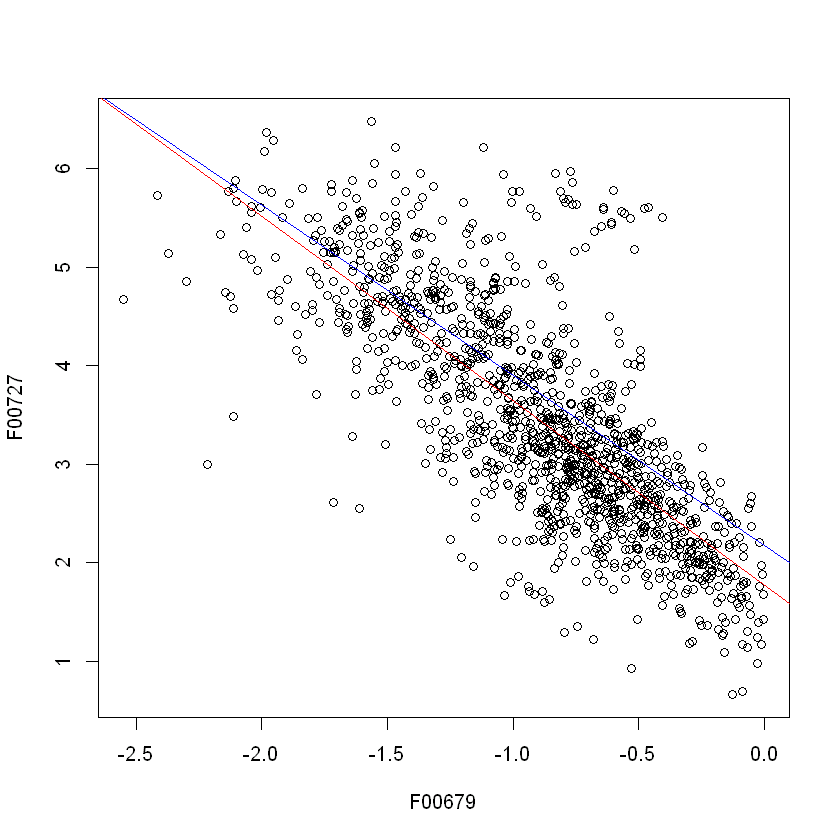

In [102]:
# log(SRL) ~ log(RD) (RD as the predictor of SRL)
#--------------------------------------------------

plot(F00727 ~ F00679, data = traits)
mod <- lm(F00727 ~ F00679, data = traits) # SRL ~ RD shows significant relationship with a strong R2
modp <- phylolm::phylolm(F00727 ~ F00679, data = traits, model = "lambda", phy = tree)
abline(mod, col = "red")
abline(modp, col = "blue")
summary(modp)


Call:
phylolm::phylolm(formula = F00727 ~ F00709, data = traits, phy = tree, 
    model = "lambda")

   AIC logLik 
  3017  -1504 

Raw residuals:
    Min      1Q  Median      3Q     Max 
-1.7749 -0.4365  0.1557  0.8936  2.9620 

Mean tip height: 400.7877
Parameter estimate(s) using ML:
lambda : 0.8167053
sigma2: 0.005329406 

Coefficients:
             Estimate    StdErr  t.value   p.value    
(Intercept)  2.015946  0.573426   3.5156 0.0004538 ***
F00709      -0.903501  0.041929 -21.5484 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-squared: 0.2633	Adjusted R-squared: 0.2628 

Note: p-values and R-squared are conditional on lambda=0.8167053.

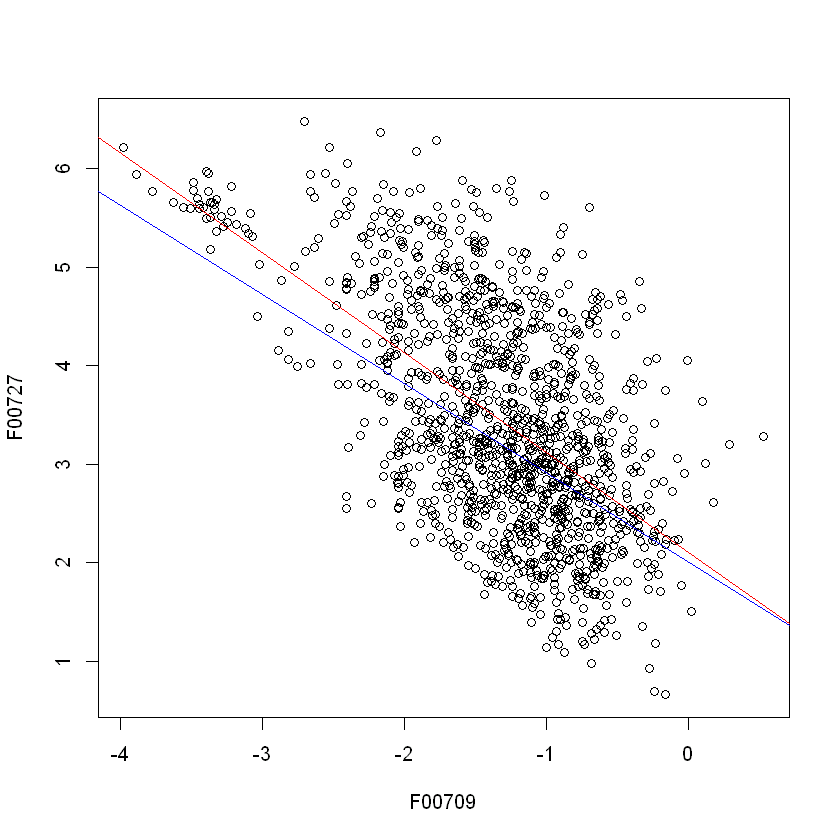

In [103]:
plot(F00727 ~ F00709, data = traits)
mod <- lm(F00727 ~ F00709, data = traits) # SRL ~ RTD also shows significant relationship with a strong R2
modp <- phylolm::phylolm(F00727 ~ F00709, data = traits, model = "lambda", phy = tree)
abline(mod, col = "red")
abline(modp, col = "blue")
summary(modp)


Call:
phylolm::phylolm(formula = F00679 ~ F00709, data = traits, phy = tree, 
    model = "lambda")

   AIC logLik 
1239.6 -615.8 

Raw residuals:
     Min       1Q   Median       3Q      Max 
-1.72362 -0.37610 -0.02484  0.25813  0.81910 

Mean tip height: 400.7877
Parameter estimate(s) using ML:
lambda : 0.8279991
sigma2: 0.001420772 

Coefficients:
             Estimate    StdErr t.value  p.value   
(Intercept) -0.839804  0.297406 -2.8238 0.004819 **
F00709      -0.021918  0.021183 -1.0347 0.300989   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-squared: 0.0008235	Adjusted R-squared: 5.435e-05 

Note: p-values and R-squared are conditional on lambda=0.8279991.

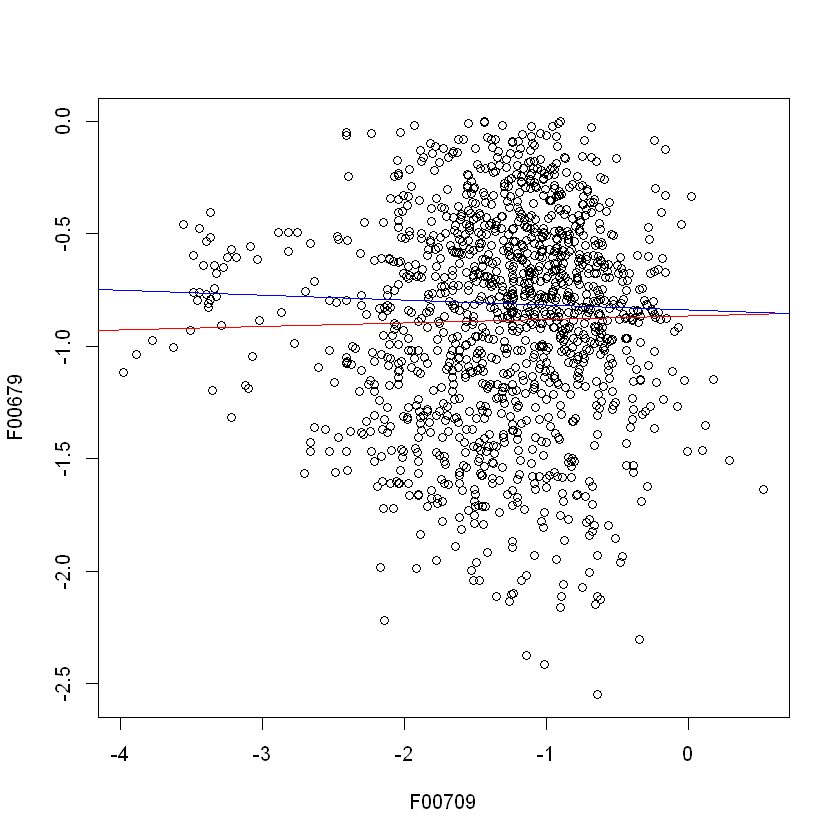

In [106]:
plot(F00679 ~ F00709, data = traits)
mod <- lm(F00679 ~ F00709, data = traits) # RD ~ RTD shows insignificant relationship with a very low R2
modp <- phylolm::phylolm(F00679 ~ F00709, data = traits, model = "lambda", phy = tree)
abline(mod, col = "red")
abline(modp, col = "blue")
summary(modp)

In [37]:
# for an explanation on non BM models - https://lukejharmon.github.io/pcm/chapter6_beyondbm/

tm <- Sys.time()

SRL_model_fits <- list()
RD_model_fits <- list()
RTD_model_fits <- list()

for (m in GEIGER_FITCONTINUOUS_MODEL_OPTIONS) {
    SRL_model_fits[[m]] <- geiger::fitContinuous(phy = tree, dat = traits["F00727"], model = m)
    RD_model_fits[[m]] <- geiger::fitContinuous(phy = tree, dat = traits["F00679"], model = m)
    RTD_model_fits[[m]] <- geiger::fitContinuous(phy = tree, dat = traits["F00709"], model = m)
    print(paste0("all ", m, " fits done!"))
}

tm <- Sys.time() - tm

save(SRL_model_fits, RD_model_fits, RTD_model_fits, file = "../../data/chapter2/rdata/SRL_RD_RTD_geiger_fitContinuous.RData")

Warning message in geiger::fitContinuous(phy = tree, dat = traits["F00727"], model = m):
"
Parameter estimates appear at bounds:
	a"
Warning message in geiger::fitContinuous(phy = tree, dat = traits["F00709"], model = m):
"
Parameter estimates appear at bounds:
	a"


In [44]:
tm # not bad at all :)

Time difference of 14.68104 mins

In [97]:
# for all the three continuous traits lambda seems to be the best model, followed by kappa and then OU??????

# AICc table

cbind(
    SRL = mapply(SRL_model_fits, FUN = function(m) m$opt$aicc),
    RD = mapply(RD_model_fits, FUN = function(m) m$opt$aicc),
    RTD = mapply(RTD_model_fits, FUN = function(m) m$opt$aicc)
)

,SRL,RD,RTD
BM,5194.320,2856.344,3753.738
OU,3929.309,1673.022,2363.545
EB,5196.349,2858.372,3755.767
rate_trend,5142.831,2805.895,3701.958
lambda,3411.727,1238.656,1939.839
kappa,3541.946,1414.510,2097.660
delta,5092.885,2757.039,3651.684
mean_trend,5196.329,2858.353,3755.747
white,4033.236,1702.775,2567.840


In [8]:
# "By including more diverse species in our phylogeny, we capture deeper splits that represent more meaningful divergences in the genotype and phenotype of extant lineages,
# precisely the effects we intend to model when analysing inter-species data."
# "One consequence of this, is that shallow topology (near the tips) is less informative than deep topology when attempting to infer patterns of phylogenetic niche conservatism, because differences between genera
# are usually more significant than differences between species within genera."

# "For higher taxonomic ranks (e.g. genus), it will usually be possible to derive a unique consensus tree by sampling a single species from each genus and simply pruning off the other tips from the tree.
# This approach may be problematic for lower taxonomic ranks however, because more closely related species are less likely to be monophyletic with respect to the taxonomic rank in question.
# Even in such cases, we can easily account for this phylogenetic uncertainty by randomly sampling topologies at the specified rank and fitting our models over this sample of trees."

In [16]:
# sample the phylogeny repeatedly, with one randomly chosen species per genera

NUNIQUE_GENERA <- length(unique(data$F01286)) # number of unique genera in our phylogeny
NSAMPLES = 100 # number of times to sample the original phylogeny
sampled_phylogenies <- list() # sampled sub phylogeneies with genera at tips
sampled_vcvs <- list()

for (i in 1:NSAMPLES) {
    sampled_species <- mapply(split.data.frame(data[, c("binominal", "F01286")], ~F01286), FUN = function(df) sample(df$binominal, 1)) # this is a vector of one randomly sampled species per each genera in the phylogeny
    subphylogeny <- ape::keep.tip(phy = phylogeny, tip = unname(sampled_species), trim.internal = TRUE) # trimmed phylogeny with one randomly sampled species per genus
    stopifnot(length(subphylogeny$tip.label)==NUNIQUE_GENERA)
                                     
    if(!ape::is.binary(subphylogeny)) subphylogeny <- ape::multi2di(subphylogeny) # make bifucracting if not already
    if(!ape::is.ultrametric(subphylogeny)) subphylogeny <- phytools::force.ultrametric(subphylogeny, method = "extend", message = FALSE) # make ultrametric if not already

    subphylogeny$tip.label <- gsub(subphylogeny$tip.label, pattern = "_[-a-z]+", replacement = '', fixed = FALSE) # replace the tip labels (binominal names) with genus names
    stopifnot(length(setdiff(subphylogeny$tip.label, unique(data$F01286))) == 0)
                              
    sampled_phylogenies[[i]] <- subphylogeny
    sampled_vcvs[[i]] <- ape::vcv.phylo(phy = subphylogeny, corr = TRUE) # computes the expected variances and covariances of a continuous phenotype assuming it evolves under a Brownian motion model
}

stopifnot(length(sampled_phylogenies) == length(sampled_vcvs))

In [ ]:
# create list of C matrices and dfs for use with brm_multiple() - DONT KNOW WTF THESE ARE????